# Master Thesis - Vignoli Lorenzo

---

## 🐙 Helyx training

## ⚙️ Import Libraries

In [2]:
# Libraries
import os
import glob
import random
import warnings
import numpy as np # type: ignore
from sklearn.model_selection import train_test_split # type: ignore

import torch # type: ignore
import torch.nn as nn # type: ignore
import torch.optim as optim # type: ignore
from torch.utils.data import Dataset, DataLoader, RandomSampler # type: ignore
import torch.nn.functional as F # type: ignore
import shutil
import plotly.graph_objects as go # type: ignore
from torch.optim.lr_scheduler import LinearLR, ReduceLROnPlateau # type: ignore
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torch.optim.swa_utils import AveragedModel, SWALR
import torch.autograd as autograd # type: ignore

import matplotlib.pyplot as plt # type: ignore
import seaborn as sns # type: ignore
import matplotlib as mpl # type: ignore
from matplotlib import rcParams # type: ignore
from cycler import cycler # type: ignore
import random
import sys
from torch.amp import GradScaler, autocast # type: ignore
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from scipy.spatial.transform import Rotation as R
from scipy.linalg import solve
from numpy.linalg import lstsq
from scipy.linalg import null_space
import torchvision.models as models
from PIL import Image

# Reconstruction utility
from MULTI_reconstruction_utility import *

# PCC model
from MULTI_jacobians import *
from MULTI_kinematics import *

# Publication-ready plotting setup with TRUE LaTeX rendering
rcParams.update({
   'figure.figsize': (6, 4), 'figure.dpi': 300, 'savefig.dpi': 300,
   'savefig.format': 'pdf', 'savefig.bbox': 'tight', 'savefig.pad_inches': 0.1,
   'font.family': 'serif', 'font.serif': ['Computer Modern Roman', 'Times New Roman', 'DejaVu Serif'],
   'font.size': 10, 'axes.titlesize': 12, 'axes.labelsize': 10,
   'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 9,
   'lines.linewidth': 1.5, 'lines.markersize': 6, 'lines.markeredgewidth': 0.5,
   'axes.linewidth': 1.0, 'axes.spines.top': False, 'axes.spines.right': False,
   'axes.grid': True, 'axes.edgecolor': 'black',
   'xtick.direction': 'in', 'ytick.direction': 'in',
   'xtick.major.size': 4, 'ytick.major.size': 4,
   'xtick.minor.size': 2, 'ytick.minor.size': 2,
   'xtick.minor.visible': True, 'ytick.minor.visible': True,
   'grid.color': 'gray', 'grid.linestyle': '-', 'grid.linewidth': 0.5, 'grid.alpha': 0.3,
   'legend.frameon': True, 'legend.framealpha': 0.9, 'legend.fancybox': False,
   'legend.edgecolor': 'black', 'legend.facecolor': 'white', 'legend.numpoints': 1,
   'text.usetex': True,  # TRUE LaTeX rendering
   'mathtext.default': 'regular',
   'axes.unicode_minus': False,
   'text.latex.preamble': r'\usepackage{amsmath}\usepackage{amsfonts}\usepackage{amssymb}'
})

sns.set_style("whitegrid", {"axes.spines.left": True, "axes.spines.bottom": True,
                          "axes.spines.top": False, "axes.spines.right": False,
                          "grid.color": "0.8", "grid.linestyle": "-", "grid.linewidth": 0.5})
pub_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
             '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
sns.set_palette(pub_colors)
rcParams['axes.prop_cycle'] = cycler('color', pub_colors)

# Ignore warnings
warnings.filterwarnings("ignore")
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = False

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print("True LaTeX rendering enabled for all plots")

Using device: cuda
True LaTeX rendering enabled for all plots


## ⏳ Load and process the Data

In [3]:
def save_tensor_as_png(tensor, path):
   """
   Save tensor as PNG image.
   """
   if tensor.dtype != torch.uint8:
       tensor = tensor.to(torch.uint8)
   
   # Convert from CHW to HWC for PIL
   if len(tensor.shape) == 3:
       tensor = tensor.permute(1, 2, 0)
   
   # Convert to numpy and save
   image_np = tensor.numpy()
   image = Image.fromarray(image_np)
   image.save(path)

In [4]:
if False:

    for split in ["train", "val", "test"]:
        shutil.rmtree(f"images_multi/{split}", ignore_errors=True)
        shutil.rmtree(f"tip1/{split}", ignore_errors=True)
        shutil.rmtree(f"tip2/{split}", ignore_errors=True)
        shutil.rmtree(f"tip3/{split}", ignore_errors=True)
        shutil.rmtree(f"quad/{split}", ignore_errors=True)
        shutil.rmtree(f"affine/{split}", ignore_errors=True)
        shutil.rmtree(f"const/{split}", ignore_errors=True)
        shutil.rmtree(f"DELTAL_sensing", ignore_errors=True)
        os.makedirs(f"images_multi/{split}", exist_ok=True)
        os.makedirs(f"tip1/{split}", exist_ok=True)
        os.makedirs(f"tip2/{split}", exist_ok=True)
        os.makedirs(f"tip3/{split}", exist_ok=True)
        os.makedirs(f"quad/{split}", exist_ok=True)
        os.makedirs(f"affine/{split}", exist_ok=True)
        os.makedirs(f"const/{split}", exist_ok=True)
        os.makedirs(f"DELTAL_sensing", exist_ok=True)

    dataset_files = sorted(glob.glob("DatasetMulti*.pt"))
    total_originals = sum([len(torch.load(f)["X_images"]) for f in dataset_files])
    all_indices = np.arange(total_originals)

    train_idx, temp_idx = train_test_split(all_indices, test_size=0.15)
    val_idx, test_idx = train_test_split(temp_idx, test_size=1/3)

    split_map = np.full(total_originals, "", dtype=object)
    split_map[train_idx] = "train"
    split_map[val_idx] = "val"
    split_map[test_idx] = "test"

    global_index = {
        "train": 0,
        "val": 0,
        "test": 0
    }

    current_idx = 0

    for file in dataset_files:

        # Process each dataset file
        print(f"\n Processing {file}...")
        data = torch.load(file)
        X_images = data["X_images"]
        X_quad = data["X_quad"]
        X_affine = data["X_affine"]
        X_const = data["X_const"]
        DELTAL = data["X_DELTAL"]
        tip_1 = data["tip_1"]
        tip_2 = data["tip_2"]
        tip_3 = data["tip_3"]
        print(f"mean tip_1[2]: {torch.stack(tip_1)[:, 2].float().mean():.4f}, "
                f"mean tip_2[2]: {torch.stack(tip_2)[:, 2].float().mean():.4f}, "
                f"mean tip_3[2]: {torch.stack(tip_3)[:, 2].float().mean():.4f}")

        for i in range(len(X_images)):

            split = split_map[current_idx]
            idx_str = f"{global_index[split]:06d}"

            # Save images as PNG
            save_tensor_as_png(X_images[i], f"images_multi/{split}/img_{idx_str}.png")
           
            # Save all labels as PT
            torch.save(tip_1[i], f"tip1/{split}/tip1_{idx_str}.pt")
            torch.save(tip_2[i], f"tip2/{split}/tip2_{idx_str}.pt")
            torch.save(tip_3[i], f"tip3/{split}/tip3_{idx_str}.pt")
            torch.save(X_quad[i], f"quad/{split}/quad_{idx_str}.pt")
            torch.save(X_affine[i], f"affine/{split}/affine_{idx_str}.pt")
            torch.save(X_const[i], f"const/{split}/const_{idx_str}.pt")
            torch.save(DELTAL[i], f"DELTAL_sensing/DELTAL_{idx_str}.pt")

            global_index[split] += 1
            current_idx += 1

            percent = (current_idx / total_originals) * 100
            sys.stdout.write(f"\rProgress: {percent:.2f}%")
            sys.stdout.flush()

        del X_images, X_quad, X_affine, X_const, tip_1, tip_2, tip_3, DELTAL

    print(f"\nFinished dataset generation, with {total_originals} total samples.")


In [5]:
if False:

   for split in ["train", "val", "test"]:
       shutil.rmtree(f"end_effector/{split}", ignore_errors=True)
       shutil.rmtree(f"DELTAL/{split}", ignore_errors=True)
       os.makedirs(f"end_effector/{split}", exist_ok=True)
       os.makedirs(f"DELTAL/{split}", exist_ok=True)

   dataset_files = sorted(glob.glob("FKdata*.pt"))
   total_originals = sum([len(torch.load(f)["DELTAL"]) for f in dataset_files])
   all_indices = np.arange(total_originals)

   train_idx, temp_idx = train_test_split(all_indices, test_size=0.15)
   val_idx, test_idx = train_test_split(temp_idx, test_size=1/3)

   split_map = np.full(total_originals, "", dtype=object)
   split_map[train_idx] = "train"
   split_map[val_idx] = "val"
   split_map[test_idx] = "test"

   global_index = {
       "train": 0,
       "val": 0,
       "test": 0
   }

   current_idx = 0

   for file in dataset_files:

       # Process each dataset file
       print(f"\n Processing {file}...")
       data = torch.load(file)
       X_DELTAL = data["DELTAL"]
       end_effector = data["tip3_pose"]

       for i in range(len(X_DELTAL)):

           split = split_map[current_idx]
           idx_str = f"{global_index[split]:06d}"
           
           # Save all labels as PT
           torch.save(X_DELTAL[i], f"DELTAL/{split}/deltal_{idx_str}.pt")
           torch.save(end_effector[i], f"end_effector/{split}/end_effector_{idx_str}.pt")

           global_index[split] += 1
           current_idx += 1

           percent = (current_idx / total_originals) * 100
           sys.stdout.write(f"\rProgress: {percent:.2f}%")
           sys.stdout.flush()

   print(f"\nFinished dataset generation, with {total_originals} total samples.")


In [6]:
# Save summary statistics for normalization
if True:
    # --- tip1 (target position + orientation) ---
    tip1_paths = sorted(glob.glob("tip1/train/*.pt"))
    all_tip1 = torch.stack([torch.load(p).float() for p in tip1_paths])
    mean_tip1 = all_tip1.mean(dim=0)
    std_tip1 = all_tip1.std(dim=0)
    torch.save({'mean': mean_tip1, 'std': std_tip1}, 'tip1_stats.pt')
    del all_tip1, mean_tip1, std_tip1

    # --- tip2 (target position + orientation) ---
    tip2_paths = sorted(glob.glob("tip2/train/*.pt"))
    all_tip2 = torch.stack([torch.load(p).float() for p in tip2_paths])
    mean_tip2 = all_tip2.mean(dim=0)
    std_tip2 = all_tip2.std(dim=0)
    torch.save({'mean': mean_tip2, 'std': std_tip2}, 'tip2_stats.pt')
    del all_tip2, mean_tip2, std_tip2

    # --- tip3 (target position + orientation) ---
    tip3_paths = sorted(glob.glob("tip3/train/*.pt"))
    all_tip3 = torch.stack([torch.load(p).float() for p in tip3_paths])
    mean_tip3 = all_tip3.mean(dim=0)
    std_tip3 = all_tip3.std(dim=0)
    torch.save({'mean': mean_tip3, 'std': std_tip3}, 'tip3_stats.pt')
    del all_tip3, mean_tip3, std_tip3

    # --- quad (shape descriptors) ---
    backbone_paths = sorted(glob.glob("quad/train/*.pt"))
    all_backbones = torch.stack([torch.load(p).float().view(-1) for p in backbone_paths])
    mean_backbone = all_backbones.mean(dim=0)
    std_backbone = all_backbones.std(dim=0)
    torch.save({'mean': mean_backbone, 'std': std_backbone}, 'quad_stats.pt')
    del all_backbones, mean_backbone, std_backbone

    # --- affine (shape descriptors) ---
    backbone_paths = sorted(glob.glob("affine/train/*.pt"))
    all_backbones = torch.stack([torch.load(p).float().view(-1) for p in backbone_paths])
    mean_backbone = all_backbones.mean(dim=0)
    std_backbone = all_backbones.std(dim=0)
    torch.save({'mean': mean_backbone, 'std': std_backbone}, 'affine_stats.pt')
    del all_backbones, mean_backbone, std_backbone

    # --- const (shape descriptors) ---
    backbone_paths = sorted(glob.glob("const/train/*.pt"))
    all_backbones = torch.stack([torch.load(p).float().view(-1) for p in backbone_paths])
    mean_backbone = all_backbones.mean(dim=0)
    std_backbone = all_backbones.std(dim=0)
    torch.save({'mean': mean_backbone, 'std': std_backbone}, 'const_stats.pt')
    del all_backbones, mean_backbone, std_backbone

    # --- inverse kinematics ---
    DELTAL_paths = sorted(glob.glob("DELTAL_sensing/*.pt"))
    all_DELTAL = torch.stack([torch.load(p).float() for p in DELTAL_paths])
    mean = all_DELTAL.mean(dim=0)
    std = all_DELTAL.std(dim=0)
    torch.save({'mean': mean, 'std':std}, 'models/kinematics/DELTAL_stats.pt')
    del all_DELTAL, mean, std

    # --- end effector (position + orientation) ---
    end_effector_paths = sorted(glob.glob("end_effector/train/*.pt"))
    all_end_effector = torch.stack([torch.load(p).float() for p in end_effector_paths])
    mean_end_effector = all_end_effector.mean(dim=0)
    std_end_effector = all_end_effector.std(dim=0)
    torch.save({'mean': mean_end_effector, 'std': std_end_effector}, 'end_effector_stats.pt')
    del all_end_effector, mean_end_effector, std_end_effector

    # --- DELTAL from FK (joint angles) ---
    deltal_fk_paths = sorted(glob.glob("DELTAL/train/*.pt"))
    all_deltal_fk = torch.stack([torch.load(p).float() for p in deltal_fk_paths])
    mean_deltal_fk = all_deltal_fk.mean(dim=0)
    std_deltal_fk = all_deltal_fk.std(dim=0)
    torch.save({'mean': mean_deltal_fk, 'std': std_deltal_fk}, 'DELTAL_fk_stats.pt')
    del all_deltal_fk, mean_deltal_fk, std_deltal_fk

## ⏳ Dataset generation

Models to be created:
1. CNN to reconstruct overall tips position
2. CNNs to reconstruct curvature (for the three approximations)
3. ANN for inverse kinematics (from 3 xyz to DELTAL)
4. ANN selector:
    - define xyz of each section based on the pose
    - use a penalty on DELTAL to avoid expensive configurations
    - use the inverse defined selector to compute the loss

In [7]:
# Image regression, valid for both pose and reconstruction
class ImageRegressionDataset(Dataset):
   """
   Creates dataset with image paths (strings) and label
   paths (list of strings).
   """
   
   def __init__(self, image_paths, label_paths, split="train"):
       self.image_paths = image_paths
       if isinstance(label_paths[0], str):
           self.label_paths = [label_paths]  # if a string, wraps in a list
       else:
           self.label_paths = label_paths    # already list
       self.augment = split == "train"

   def __len__(self):
       return len(self.image_paths)

   def load_image(self, path):
       """Load PNG image and convert to tensor format (C, H, W)"""
       image = Image.open(path).convert('RGB')
       image = TF.to_tensor(image)  # converts to [0,1] float
       image = (image * 255).to(torch.uint8)  # convert to [0,255] uint8
       return image

   def apply_blur(self, image, kernel_size=5, sigma_max=8.0):
       sigma = random.uniform(0.0, sigma_max)
       image = image.float().unsqueeze(0) / 255.0
       image = TF.gaussian_blur(image, kernel_size=kernel_size, sigma=sigma)
       return (image.squeeze(0) * 255.0).clamp(0, 255).to(torch.uint8)

   def add_gaussian_noise(self, image, std_max=30.0):
       std = random.uniform(0.0, std_max)
       noise = torch.randn_like(image.float()) * std
       image = image.float() + noise
       return image.clamp(0, 255).to(torch.uint8)

   def apply_color_jitter(self, image, brightness=0.4, contrast=0.4):
       image = image.float().unsqueeze(0) / 255.0
       b = 1.0 + random.uniform(-brightness, brightness)
       c = 1.0 + random.uniform(-contrast, contrast)
       image = TF.adjust_brightness(image, b)
       image = TF.adjust_contrast(image, c)
       return (image.squeeze(0) * 255.0).clamp(0, 255).to(torch.uint8)

   def apply_brightness_shift(self, image, offset_max=0.3):
       offset = random.choice([-offset_max, offset_max])
       image = (image.float() / 255.0 + offset).clamp(0.0, 1.0)
       return (image * 255.0).to(torch.uint8)

   def apply_vignette(self, image, strength_max=0.6):
       strength = strength_max
       H, W = image.shape[1:]
       Y, X = torch.meshgrid(torch.linspace(-1, 1, H), torch.linspace(-1, 1, W), indexing='ij')
       radius = torch.sqrt(X**2 + Y**2)
       mask = 1.0 - strength * radius**2
       mask = mask.clamp(0.75, 1.0).unsqueeze(0)
       image = (image.float() / 255.0 * mask).clamp(0.0, 1.0)
       return (image * 255.0).to(torch.uint8)
   
   def apply_cutout(self, image, num_patches_range=(1, 3), max_ratio=0.5):
       C, H, W = image.shape
       num_patches = random.randint(*num_patches_range)
       for _ in range(num_patches):
           patch_h = int(random.uniform(0.0, max_ratio) * H)
           patch_w = int(random.uniform(0.0, max_ratio) * W)
           if patch_h == 0 or patch_w == 0:
               continue
           top = random.randint(0, H - patch_h)
           left = random.randint(0, W - patch_w)
           image[:, top:top + patch_h, left:left + patch_w] = 0  # black patch
       return image

   def __getitem__(self, idx):
       image = self.load_image(self.image_paths[idx])
       labels = [torch.load(paths[idx]).float().view(-1) for paths in self.label_paths]
       label = torch.cat(labels, dim=0)

       if self.augment:
           image = self.apply_blur(image)
           image = self.add_gaussian_noise(image)
           image = self.apply_color_jitter(image)
           image = self.apply_brightness_shift(image)
           image = self.apply_vignette(image)
           image = self.apply_cutout(image)

       label = label.view(-1)

       return image, label
   
# Generic path loader for images and target
def get_paths(split, target_folders):
   """
   Gets path for images and labels, and restitutes:
   - Image for single path
   - Label for a list, in case there are more
   """

   image_dir = os.path.join("images_multi", split)

   image_paths = sorted([
       os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.endswith(".png")
   ])

   if isinstance(target_folders, str):
       target_folders = [target_folders]   # case of single target, wraps in list (curvature)

   label_paths = []
   for folder in target_folders:
       target_dir = os.path.join(folder, split)
       paths = sorted([
           os.path.join(target_dir, f) for f in os.listdir(target_dir) if f.endswith(".pt")
       ])
       assert len(image_paths) == len(paths), f"Mismatch in {split} set for {folder}"
       label_paths.append(paths)

   return image_paths, label_paths


In [8]:
# Forward kinematics, valid from DELTAL to p
class FKDataset(Dataset):
    """
    Creates dataset for forward kinematics.
    """
    
    def __init__(self, input_paths, label_paths):
        self.input_paths = input_paths
        self.label_paths = label_paths

    def __len__(self):
        return len(self.label_paths)
    
    def __getitem__(self, idx):
        input_tensor = torch.load(self.input_paths[idx]).float()
        label_tensor = torch.load(self.label_paths[idx]).float()
        return input_tensor, label_tensor
    
def get_paths_FK(split):
    """
    Gets path for inputs and labels, and restitutes:
    - Input paths (DELTAL)
    - Label paths (end_effector)
    """

    label_dir = os.path.join("end_effector", split)
    label_paths = sorted([os.path.join(label_dir, f) for f in os.listdir(label_dir) if f.endswith(".pt")])
    input_dir = os.path.join("DELTAL", split)
    input_paths = sorted([os.path.join(input_dir, f) for f in os.listdir(input_dir) if f.endswith(".pt")])
    return input_paths, label_paths


In [9]:
# === First stage: training on tip pose ===
train_img_y, train_lbl_y = get_paths("train", ["tip1", "tip2", "tip3"])
val_img_y, val_lbl_y = get_paths("val", ["tip1", "tip2", "tip3"])
test_img_y, test_lbl_y = get_paths("test", ["tip1", "tip2", "tip3"])

train_dataset_y = ImageRegressionDataset(train_img_y, train_lbl_y, split="train")
val_dataset_y = ImageRegressionDataset(val_img_y, val_lbl_y, split="val")
test_dataset_y = ImageRegressionDataset(test_img_y, test_lbl_y, split="test")

# Shared sampler
shared_sampler = RandomSampler(train_dataset_y)

train_loader_y = DataLoader(train_dataset_y, batch_size=16, sampler=shared_sampler,
                            num_workers=12, pin_memory=True, persistent_workers=True)
val_loader_y = DataLoader(val_dataset_y, batch_size=16, shuffle=False,
                          num_workers=12, pin_memory=True, persistent_workers=True)
test_loader_y = DataLoader(test_dataset_y, batch_size=16, shuffle=False,
                           num_workers=12, pin_memory=True, persistent_workers=True)

# === Second stage: training on shape descriptors ===
target_folders = ["quad", "affine", "const"]
curvature_loaders = {}

# To use it, e.g. curvature_loaders["quad"]["train"], for all target folders
for target in target_folders:
    train_img, train_lbl = get_paths("train", target)
    val_img, val_lbl = get_paths("val", target)
    test_img, test_lbl = get_paths("test", target)

    train_ds = ImageRegressionDataset(train_img, train_lbl, split="train")
    val_ds = ImageRegressionDataset(val_img, val_lbl, split="val")
    test_ds = ImageRegressionDataset(test_img, test_lbl, split="test")

    train_loader = DataLoader(train_ds, batch_size=16, sampler=shared_sampler,
                              num_workers=12, pin_memory=True, persistent_workers=True)
    val_loader = DataLoader(val_ds, batch_size=16, shuffle=False,
                            num_workers=12, pin_memory=True, persistent_workers=True)
    test_loader = DataLoader(test_ds, batch_size=16, shuffle=False,
                             num_workers=12, pin_memory=True, persistent_workers=True)

    curvature_loaders[target] = {
        "train": train_loader,
        "val": val_loader,
        "test": test_loader
    }

del train_loader, val_loader, test_loader

# === Third stage: forward kinematics ===
train_inputs, train_labels = get_paths_FK("train")
val_inputs, val_labels = get_paths_FK("val")
test_inputs, test_labels = get_paths_FK("test")

train_dataset = FKDataset(train_inputs, train_labels)
val_dataset = FKDataset(val_inputs, val_labels)
test_dataset = FKDataset(test_inputs, test_labels)

train_loader_FK = DataLoader(train_dataset, batch_size=64, shuffle=True,
                         num_workers=12, pin_memory=True, persistent_workers=True)
val_loader_FK = DataLoader(val_dataset, batch_size=64, shuffle=False,
                       num_workers=12, pin_memory=True, persistent_workers=True)
test_loader_FK = DataLoader(test_dataset, batch_size=64, shuffle=False,
                        num_workers=12, pin_memory=True, persistent_workers=True)

## 😓 Training of pose estimator

In [10]:
# Model for denormalization
class DenormalizedModel(nn.Module):
    def __init__(self, base_model, mean, std):
        super().__init__()
        self.base_model = base_model
        self.register_buffer("mean", mean)
        self.register_buffer("std", std)

    def forward(self, x):
        out = self.base_model(x)
        return out * self.std + self.mean

# Model for 3 grayscale images CNN regression 
class NetCameraBW3x(nn.Module):
    def __init__(self):
        super().__init__()

        # Load pretrained MobileNetV2
        mobilenet = models.mobilenet_v2(pretrained=True)

        # Backbone: use directly the convolutional part
        self.backbone = mobilenet.features      # [B, 1280, H/32, W/32]
        self.pool = nn.AdaptiveAvgPool2d(1)     # [B, 1280, 1, 1]

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1280, 512),
            nn.LeakyReLU(),
            nn.Linear(512, 18)
        )

    def forward(self, x):
        x = x / 255.0   # normalization from [0, 255] → [0, 1]

        x = self.backbone(x)
        x = self.pool(x)

        return self.head(x)

In [11]:
model = NetCameraBW3x().to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

criterion = nn.HuberLoss(delta=1.0)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-6)

scheduler = LinearLR(optimizer, start_factor=1e-3, end_factor=1.0, total_iters=10)
plateau_scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.6, patience=5, verbose=True)

best_val_loss = float('inf')
PATIENCE = 50
counter = 0

tip1_stats = torch.load("tip1_stats.pt")
tip2_stats = torch.load("tip2_stats.pt")
tip3_stats = torch.load("tip3_stats.pt")
mean = torch.cat([tip1_stats['mean'], tip2_stats['mean'], tip3_stats['mean']], dim=0).to(device)
std = torch.cat([tip1_stats['std'], tip2_stats['std'], tip3_stats['std']], dim=0).to(device)
history_train = []
history_val = []

scaler = GradScaler()
accumulation_steps = max(1, len(train_loader_y) // 8)
optimizer.zero_grad()
epochs = 500

max_grad_norm = 1.0

angle_indices = [3, 4, 5, 9, 10, 11, 15, 16, 17]
position_indices = [0, 1, 2, 6, 7, 8, 12, 13, 14]

if True:
    for epoch in range(epochs):
        model.train()
        train_losses = []
        total_batches = len(train_loader_y)

        for i, (images, labels) in enumerate(train_loader_y):
            images = images.to(device)
            labels = labels.to(device)

            with autocast(device_type='cuda'):
                # Normalize positions only
                labels_pos_norm = (labels[:, position_indices] - mean[position_indices]) / std[position_indices]
                angles_true = labels[:, angle_indices]

                # Extend labels with sin/cos
                labels_ext = torch.cat((
                    labels_pos_norm,
                    torch.sin(angles_true),
                    torch.cos(angles_true)
                ), dim=1)

                preds = model(images)
                preds_pos = preds[:, position_indices]
                preds_angles = preds[:, angle_indices]
                
                # Extend predictions with sin/cos
                preds_ext = torch.cat((
                    preds_pos,
                    torch.sin(preds_angles),
                    torch.cos(preds_angles)
                ), dim=1)

                loss = criterion(preds_ext, labels_ext)

            loss = loss / accumulation_steps
            scaler.scale(loss).backward()

            train_losses.append(loss.item() * accumulation_steps)

            progress = (i + 1) / total_batches * 100
            sys.stdout.write(f"\rEpoch {epoch + 1}: {progress:.1f}%")
            sys.stdout.flush()

            if (i + 1) % accumulation_steps == 0 or (i + 1) == total_batches:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
                
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

        model.eval()
        val_losses = []

        with torch.no_grad():
            for images, labels in val_loader_y:
                images = images.to(device)
                labels = labels.to(device)

                with autocast(device_type='cuda'):
                    # Normalize positions only
                    labels_pos_norm = (labels[:, position_indices] - mean[position_indices]) / std[position_indices]
                    angles_true = labels[:, angle_indices]

                    # Extend labels with sin/cos
                    labels_ext = torch.cat((
                        labels_pos_norm,
                        torch.sin(angles_true),
                        torch.cos(angles_true)
                    ), dim=1)

                    preds = model(images)
                    preds_pos = preds[:, position_indices]
                    preds_angles = preds[:, angle_indices]
                    
                    # Extend predictions with sin/cos
                    preds_ext = torch.cat((
                        preds_pos,
                        torch.sin(preds_angles),
                        torch.cos(preds_angles)
                    ), dim=1)

                    loss = criterion(preds_ext, labels_ext)

                val_losses.append(loss.item())

        avg_train_loss = np.mean(train_losses)
        avg_val_loss = np.mean(val_losses)
        
        # Step schedulers
        if epoch < 10:
            scheduler.step()
        plateau_scheduler.step(avg_val_loss)

        history_train.append(avg_train_loss)
        history_val.append(avg_val_loss)

        sys.stdout.write("\r")
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch + 1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {current_lr:.6f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model, "models/vision/helyx_model_normalized.pt")
            counter = 0
        else:
            counter += 1
            if counter >= PATIENCE:
                print("Early stopping triggered.")
                break

    # Save training history
    history_multi = {
        'train': history_train,
        'val': history_val
    }
    np.save('history_multi.npy', history_multi)

    del model, tip1_stats, tip2_stats, tip3_stats
    del mean, std
    del optimizer, scheduler, plateau_scheduler, scaler
    del history_train, history_val

model = torch.load("models/vision/helyx_model_normalized.pt")
tip1_stats = torch.load("tip1_stats.pt")
tip2_stats = torch.load("tip2_stats.pt")
tip3_stats = torch.load("tip3_stats.pt")

model = model.to(device)
mean = torch.cat([tip1_stats['mean'], tip2_stats['mean'], tip3_stats['mean']], dim=0).to(device)
std = torch.cat([tip1_stats['std'], tip2_stats['std'], tip3_stats['std']], dim=0).to(device)

# Set angle normalization to identity
mean[angle_indices] = 0.0
std[angle_indices] = 1.0

if hasattr(model, 'module'):
    actual_model = model.module
else:
    actual_model = model

final_model = DenormalizedModel(actual_model, mean, std)
scripted_model = torch.jit.script(final_model)
scripted_model.save("models/vision/helyx_model.pt")

del final_model, scripted_model, tip1_stats, tip2_stats, tip3_stats

Total trainable parameters: 2,888,978
Epoch 1 | Train Loss: 0.1641 | Val Loss: 0.1653 | LR: 0.000101
Epoch 2 | Train Loss: 0.1589 | Val Loss: 0.1523 | LR: 0.000201
Epoch 3 | Train Loss: 0.1228 | Val Loss: 0.0974 | LR: 0.000301
Epoch 4 | Train Loss: 0.0723 | Val Loss: 0.0436 | LR: 0.000401
Epoch 5 | Train Loss: 0.0532 | Val Loss: 0.0426 | LR: 0.000501
Epoch 6 | Train Loss: 0.0442 | Val Loss: 0.0311 | LR: 0.000600
Epoch 7 | Train Loss: 0.0390 | Val Loss: 0.0318 | LR: 0.000700
Epoch 8 | Train Loss: 0.0347 | Val Loss: 0.0324 | LR: 0.000800
Epoch 9 | Train Loss: 0.0368 | Val Loss: 0.0362 | LR: 0.000900
Epoch 10 | Train Loss: 0.0326 | Val Loss: 0.0276 | LR: 0.001000
Epoch 11 | Train Loss: 0.0305 | Val Loss: 0.0312 | LR: 0.001000
Epoch 12 | Train Loss: 0.0272 | Val Loss: 0.0232 | LR: 0.001000
Epoch 13 | Train Loss: 0.0254 | Val Loss: 0.0243 | LR: 0.001000
Epoch 14 | Train Loss: 0.0245 | Val Loss: 0.0283 | LR: 0.001000
Epoch 15 | Train Loss: 0.0246 | Val Loss: 0.0327 | LR: 0.001000
Epoch 16 | 

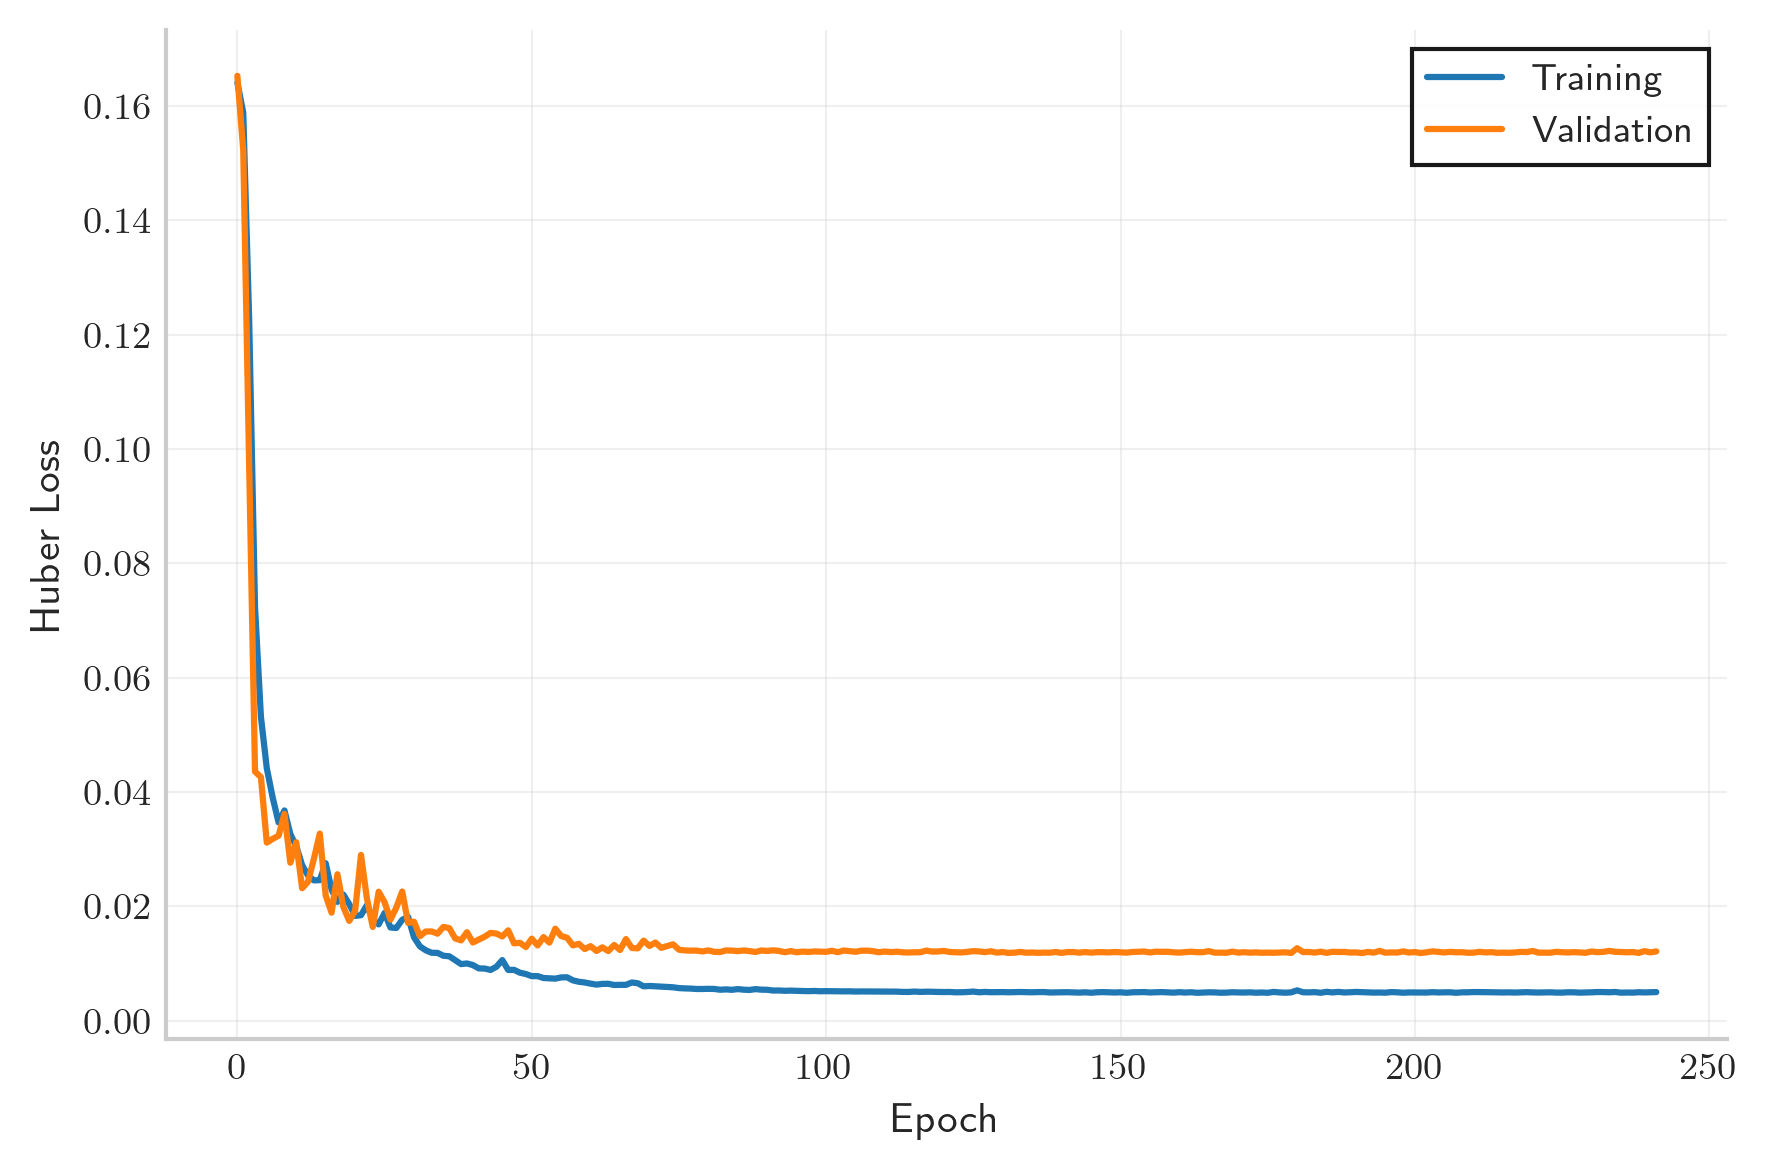

In [10]:
# Load history from file
history_multi = np.load('history_multi.npy', allow_pickle=True).item()
history_train = history_multi['train']
history_val = history_multi['val']

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history_train, label='Training', linewidth=1.5)
ax.plot(history_val, label='Validation', linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Huber Loss')
ax.legend()
ax.tick_params(which='both', direction='in')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 😓 Training of reconstructors

In [13]:
# Redefine the model for denormalization, as all need the normalized one for transfer learning
class DenormalizedModel(nn.Module):
    def __init__(self, base_model, mean, std):
        super().__init__()
        self.base_model = base_model
        self.register_buffer("mean", mean)
        self.register_buffer("std", std)

    def forward(self, x):
        out = self.base_model(x)
        return out * self.std + self.mean

Quadratic curvature model

In [14]:
wrapped_model = torch.load("models/vision/helyx_model_normalized.pt", map_location=device)

model_new = NetCameraBW3x()

model_new.load_state_dict(wrapped_model.state_dict(), strict=False)

model_new.head = nn.Sequential(
    nn.Flatten(),
    nn.Linear(1280, 512),
    nn.LeakyReLU(),
    nn.Linear(512, 15)
)

model_new = model_new.to(device)

total_params = sum(p.numel() for p in model_new.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

criterion = nn.HuberLoss(delta=1.0)
optimizer = optim.Adam(model_new.parameters(), lr=1e-3, weight_decay=5e-6)

scheduler = LinearLR(optimizer, start_factor=1e-3, end_factor=1.0, total_iters=10)
plateau_scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.6, patience=5, verbose=True)

stats = torch.load("quad_stats.pt")
mean = stats['mean'].to(device)
std = stats['std'].to(device)

best_val_loss = float('inf')
PATIENCE = 50
counter = 0
history_train = []
history_val = []

scaler = GradScaler()
accumulation_steps = max(1, len(curvature_loaders["quad"]["train"]) // 8)
optimizer.zero_grad()
epochs = 500

max_grad_norm = 1.0

angle_idx = [4, 9, 14]
non_angle_idx = [i for i in range(15) if i not in angle_idx]

if True:
    for epoch in range(epochs):
        model_new.train()
        train_losses = []
        total_batches = len(curvature_loaders["quad"]["train"])

        for i, (images, labels) in enumerate(curvature_loaders["quad"]["train"]):
            images = images.to(device)
            labels = labels.to(device)

            with autocast(device_type='cuda'):
                labels_non_angle = (labels[:, non_angle_idx] - mean[non_angle_idx]) / std[non_angle_idx]
                phi_true = labels[:, angle_idx]

                labels_ext = torch.cat((
                    labels_non_angle,
                    torch.sin(phi_true),
                    torch.cos(phi_true)),
                dim=1)

                preds_raw = model_new(images)
                preds_non_angle = preds_raw[:, non_angle_idx]
                phi_pred = preds_raw[:, angle_idx]
                preds_ext = torch.cat((
                    preds_non_angle,
                    torch.sin(phi_pred),
                    torch.cos(phi_pred)),
                dim=1)

                loss = criterion(preds_ext, labels_ext)

            loss = loss / accumulation_steps
            scaler.scale(loss).backward()

            train_losses.append(loss.item() * accumulation_steps)

            progress = (i + 1) / total_batches * 100
            sys.stdout.write(f"\rEpoch {epoch + 1}: {progress:.1f}%")
            sys.stdout.flush()

            if (i + 1) % accumulation_steps == 0 or (i + 1) == total_batches:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model_new.parameters(), max_grad_norm)
                
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

        model_new.eval()
        val_losses = []

        with torch.no_grad():
            for images, labels in curvature_loaders["quad"]["val"]:
                images = images.to(device)
                labels = labels.to(device)

                with autocast(device_type='cuda'):
                    labels_non_angle = (labels[:, non_angle_idx] - mean[non_angle_idx]) / std[non_angle_idx]
                    phi_true = labels[:, angle_idx]

                    labels_ext = torch.cat((
                        labels_non_angle,
                        torch.sin(phi_true),
                        torch.cos(phi_true)),
                    dim=1)

                    preds_raw = model_new(images)
                    preds_non_angle = preds_raw[:, non_angle_idx]
                    phi_pred = preds_raw[:, angle_idx]
                    preds_ext = torch.cat((
                        preds_non_angle,
                        torch.sin(phi_pred),
                        torch.cos(phi_pred)),
                    dim=1)

                    loss = criterion(preds_ext, labels_ext)

                val_losses.append(loss.item())

        avg_train_loss = np.mean(train_losses)
        avg_val_loss = np.mean(val_losses)
        
        # Step schedulers
        if epoch < 10:
            scheduler.step()
        plateau_scheduler.step(avg_val_loss)

        history_train.append(avg_train_loss)
        history_val.append(avg_val_loss)

        sys.stdout.write("\r")
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch + 1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {current_lr:.6f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model_new, "helyx_quad_curvature_normalized.pt")
            counter = 0
        else:
            counter += 1
            if counter >= PATIENCE:
                print("Early stopping triggered.")
                break

    # Save training history
    history_multi = {
        'train': history_train,
        'val': history_val
    }
    np.save('history_multi_quad.npy', history_multi)

    del model_new, stats, mean, std
    del optimizer, scheduler, plateau_scheduler, scaler
    del history_train, history_val

model = torch.load("helyx_quad_curvature_normalized.pt")
stats = torch.load("quad_stats.pt")

model = model.to(device)
mean = stats['mean'].to(device)
std = stats['std'].to(device)

mean[angle_idx] = 0.0
std[angle_idx] = 1.0

if hasattr(model, 'module'):
    actual_model = model.module
else:
    actual_model = model

final_model = DenormalizedModel(actual_model, mean, std)
scripted_model = torch.jit.script(final_model)
scripted_model.save("models/curvature/quadratic_model.pt")

del final_model, scripted_model, stats

Total trainable parameters: 2,887,439
Epoch 1 | Train Loss: 0.3434 | Val Loss: 0.3190 | LR: 0.000101
Epoch 2 | Train Loss: 0.3198 | Val Loss: 0.2611 | LR: 0.000201
Epoch 3 | Train Loss: 0.2477 | Val Loss: 0.1841 | LR: 0.000301
Epoch 4 | Train Loss: 0.1966 | Val Loss: 0.1544 | LR: 0.000401
Epoch 5 | Train Loss: 0.1671 | Val Loss: 0.1349 | LR: 0.000501
Epoch 6 | Train Loss: 0.1461 | Val Loss: 0.1183 | LR: 0.000600
Epoch 7 | Train Loss: 0.1328 | Val Loss: 0.1152 | LR: 0.000700
Epoch 8 | Train Loss: 0.1242 | Val Loss: 0.1167 | LR: 0.000800
Epoch 9 | Train Loss: 0.1165 | Val Loss: 0.1084 | LR: 0.000900
Epoch 10 | Train Loss: 0.1138 | Val Loss: 0.1221 | LR: 0.001000
Epoch 11 | Train Loss: 0.1058 | Val Loss: 0.1161 | LR: 0.001000
Epoch 12 | Train Loss: 0.0993 | Val Loss: 0.1146 | LR: 0.001000
Epoch 13 | Train Loss: 0.0972 | Val Loss: 0.1119 | LR: 0.001000
Epoch 14 | Train Loss: 0.0885 | Val Loss: 0.0964 | LR: 0.001000
Epoch 15 | Train Loss: 0.0820 | Val Loss: 0.1100 | LR: 0.001000
Epoch 16 | 

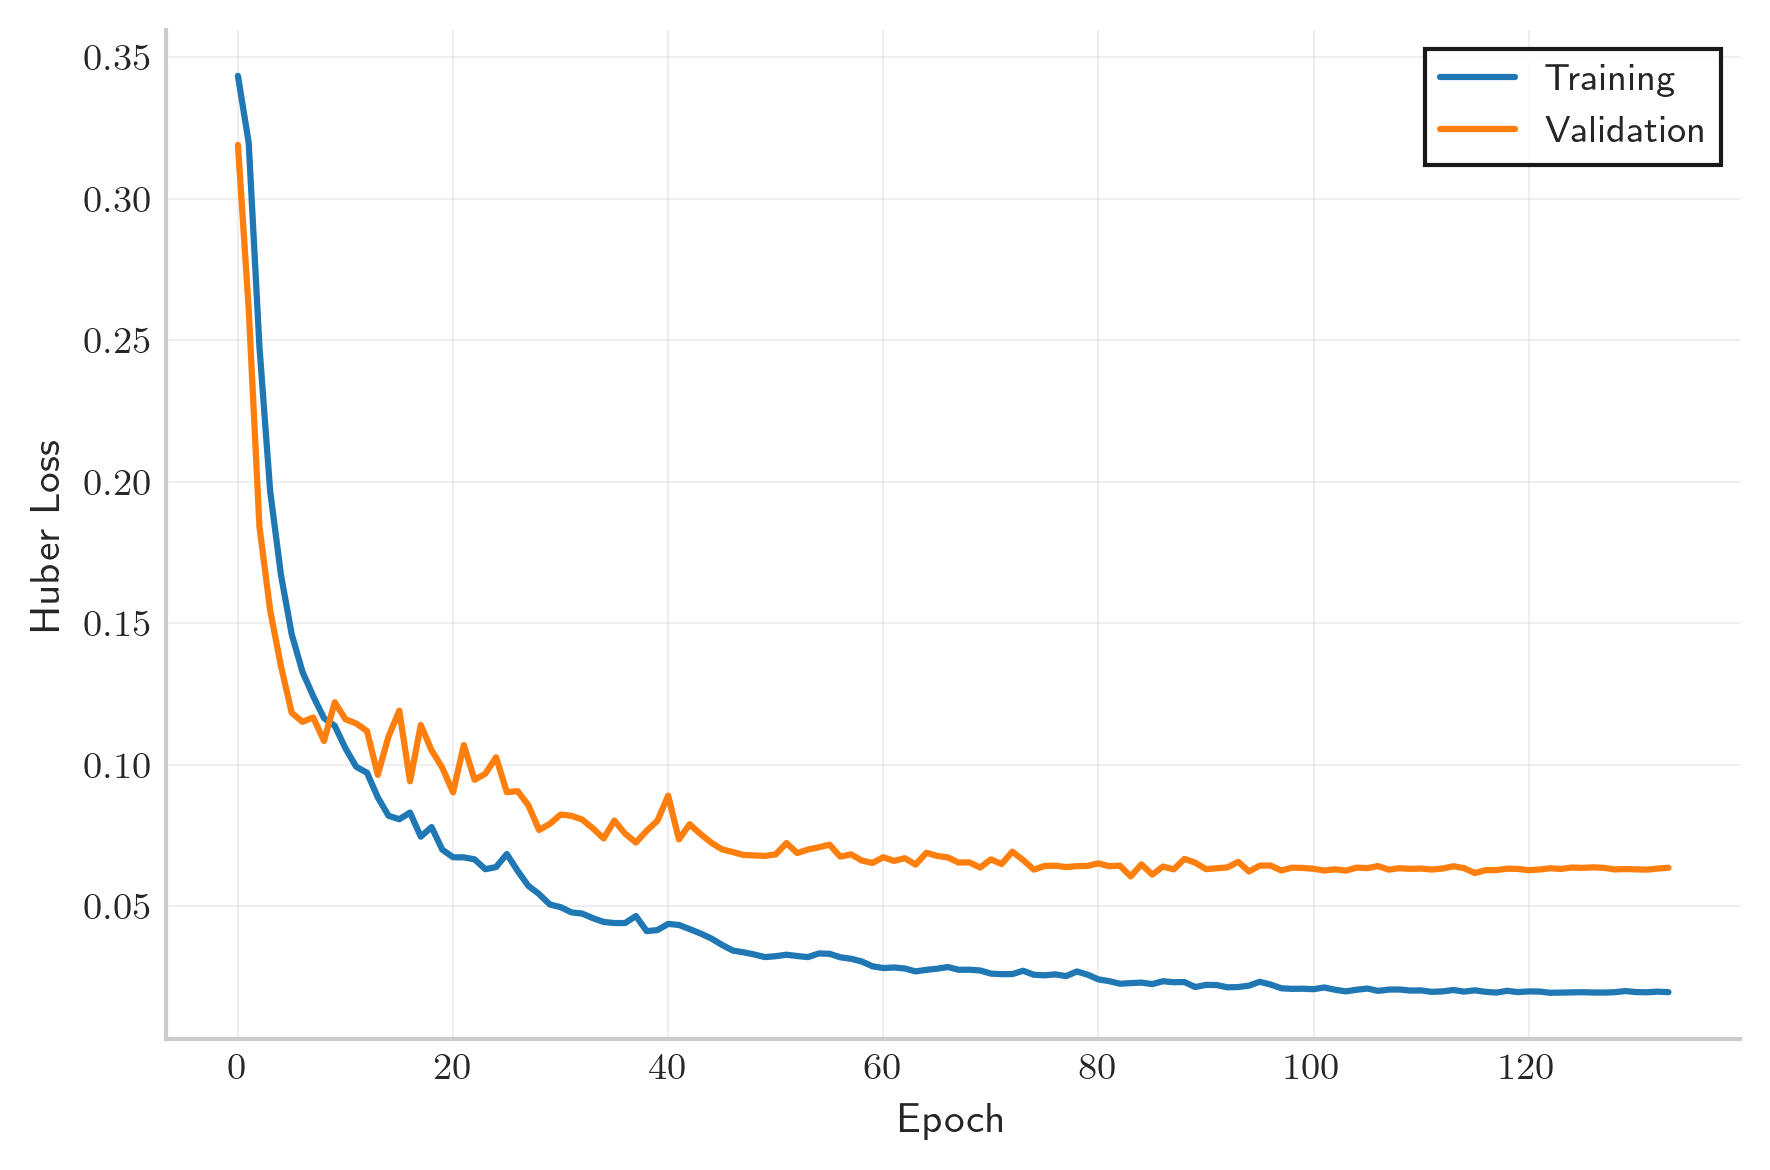

In [11]:
# Load history from file
history_multi = np.load('history_multi_quad.npy', allow_pickle=True).item()
history_train = history_multi['train']
history_val = history_multi['val']

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history_train, label='Training', linewidth=1.5)
ax.plot(history_val, label='Validation', linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Huber Loss')
ax.legend()
ax.tick_params(which='both', direction='in')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Affine curvature model

In [16]:
wrapped_model = torch.load("models/vision/helyx_model_normalized.pt", map_location=device)

model_new = NetCameraBW3x()

model_new.load_state_dict(wrapped_model.state_dict(), strict=False)

model_new.head = nn.Sequential(
    nn.Flatten(),
    nn.Linear(1280, 512),
    nn.LeakyReLU(),
    nn.Linear(512, 12)
)

model_new = model_new.to(device)

total_params = sum(p.numel() for p in model_new.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

criterion = nn.HuberLoss(delta=1.0)
optimizer = optim.Adam(model_new.parameters(), lr=1e-3, weight_decay=5e-6)

scheduler = LinearLR(optimizer, start_factor=1e-3, end_factor=1.0, total_iters=10)
plateau_scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.6, patience=5, verbose=True)

stats = torch.load("affine_stats.pt")
mean = stats['mean'].to(device)
std = stats['std'].to(device)

best_val_loss = float('inf')
PATIENCE = 50
counter = 0
history_train = []
history_val = []

scaler = GradScaler()
accumulation_steps = max(1, len(curvature_loaders["affine"]["train"]) // 8)
optimizer.zero_grad()
epochs = 500

max_grad_norm = 1.0

angle_idx = [3, 7, 11]
non_angle_idx = [i for i in range(12) if i not in angle_idx]

if True:
    for epoch in range(epochs):
        model_new.train()
        train_losses = []
        total_batches = len(curvature_loaders["affine"]["train"])

        for i, (images, labels) in enumerate(curvature_loaders["affine"]["train"]):
            images = images.to(device)
            labels = labels.to(device)

            with autocast(device_type='cuda'):
                labels_non_angle = (labels[:, non_angle_idx] - mean[non_angle_idx]) / std[non_angle_idx]
                phi_true = labels[:, angle_idx]

                labels_ext = torch.cat((
                    labels_non_angle,
                    torch.sin(phi_true),
                    torch.cos(phi_true)),
                dim=1)

                preds_raw = model_new(images)
                preds_non_angle = preds_raw[:, non_angle_idx]
                phi_pred = preds_raw[:, angle_idx]
                preds_ext = torch.cat((
                    preds_non_angle,
                    torch.sin(phi_pred),
                    torch.cos(phi_pred)),
                dim=1)

                loss = criterion(preds_ext, labels_ext)

            loss = loss / accumulation_steps
            scaler.scale(loss).backward()

            train_losses.append(loss.item() * accumulation_steps)

            progress = (i + 1) / total_batches * 100
            sys.stdout.write(f"\rEpoch {epoch + 1}: {progress:.1f}%")
            sys.stdout.flush()

            if (i + 1) % accumulation_steps == 0 or (i + 1) == total_batches:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model_new.parameters(), max_grad_norm)
                
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

        model_new.eval()
        val_losses = []

        with torch.no_grad():
            for images, labels in curvature_loaders["affine"]["val"]:
                images = images.to(device)
                labels = labels.to(device)

                with autocast(device_type='cuda'):
                    labels_non_angle = (labels[:, non_angle_idx] - mean[non_angle_idx]) / std[non_angle_idx]
                    phi_true = labels[:, angle_idx]

                    labels_ext = torch.cat((
                        labels_non_angle,
                        torch.sin(phi_true),
                        torch.cos(phi_true)),
                    dim=1)

                    preds_raw = model_new(images)
                    preds_non_angle = preds_raw[:, non_angle_idx]
                    phi_pred = preds_raw[:, angle_idx]
                    preds_ext = torch.cat((
                        preds_non_angle,
                        torch.sin(phi_pred),
                        torch.cos(phi_pred)),
                    dim=1)

                    loss = criterion(preds_ext, labels_ext)

                val_losses.append(loss.item())

        avg_train_loss = np.mean(train_losses)
        avg_val_loss = np.mean(val_losses)
        
        # Step schedulers
        if epoch < 10:
            scheduler.step()
        plateau_scheduler.step(avg_val_loss)

        history_train.append(avg_train_loss)
        history_val.append(avg_val_loss)

        sys.stdout.write("\r")
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch + 1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {current_lr:.6f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model_new, "helyx_affine_curvature_normalized.pt")
            counter = 0
        else:
            counter += 1
            if counter >= PATIENCE:
                print("Early stopping triggered.")
                break

    # Save training history
    history_multi = {
        'train': history_train,
        'val': history_val
    }
    np.save('history_multi_affine.npy', history_multi)

    del model_new, stats, mean, std
    del optimizer, scheduler, plateau_scheduler, scaler
    del history_train, history_val

model = torch.load("helyx_affine_curvature_normalized.pt")
stats = torch.load("affine_stats.pt")

model = model.to(device)
mean = stats['mean'].to(device)
std = stats['std'].to(device)

mean[angle_idx] = 0.0
std[angle_idx] = 1.0

if hasattr(model, 'module'):
    actual_model = model.module
else:
    actual_model = model

final_model = DenormalizedModel(actual_model, mean, std)
scripted_model = torch.jit.script(final_model)
scripted_model.save("models/curvature/affine_model.pt")

del final_model, scripted_model, stats

Total trainable parameters: 2,885,900
Epoch 1 | Train Loss: 0.3328 | Val Loss: 0.3126 | LR: 0.000101
Epoch 2 | Train Loss: 0.3103 | Val Loss: 0.2543 | LR: 0.000201
Epoch 3 | Train Loss: 0.2350 | Val Loss: 0.1741 | LR: 0.000301
Epoch 4 | Train Loss: 0.1796 | Val Loss: 0.1432 | LR: 0.000401
Epoch 5 | Train Loss: 0.1521 | Val Loss: 0.1229 | LR: 0.000501
Epoch 6 | Train Loss: 0.1357 | Val Loss: 0.1155 | LR: 0.000600
Epoch 7 | Train Loss: 0.1276 | Val Loss: 0.1163 | LR: 0.000700
Epoch 8 | Train Loss: 0.1181 | Val Loss: 0.1029 | LR: 0.000800
Epoch 9 | Train Loss: 0.1088 | Val Loss: 0.1047 | LR: 0.000900
Epoch 10 | Train Loss: 0.1180 | Val Loss: 0.1024 | LR: 0.001000
Epoch 11 | Train Loss: 0.1017 | Val Loss: 0.1031 | LR: 0.001000
Epoch 12 | Train Loss: 0.0959 | Val Loss: 0.0945 | LR: 0.001000
Epoch 13 | Train Loss: 0.0876 | Val Loss: 0.0923 | LR: 0.001000
Epoch 14 | Train Loss: 0.0904 | Val Loss: 0.0928 | LR: 0.001000
Epoch 15 | Train Loss: 0.0855 | Val Loss: 0.1021 | LR: 0.001000
Epoch 16 | 

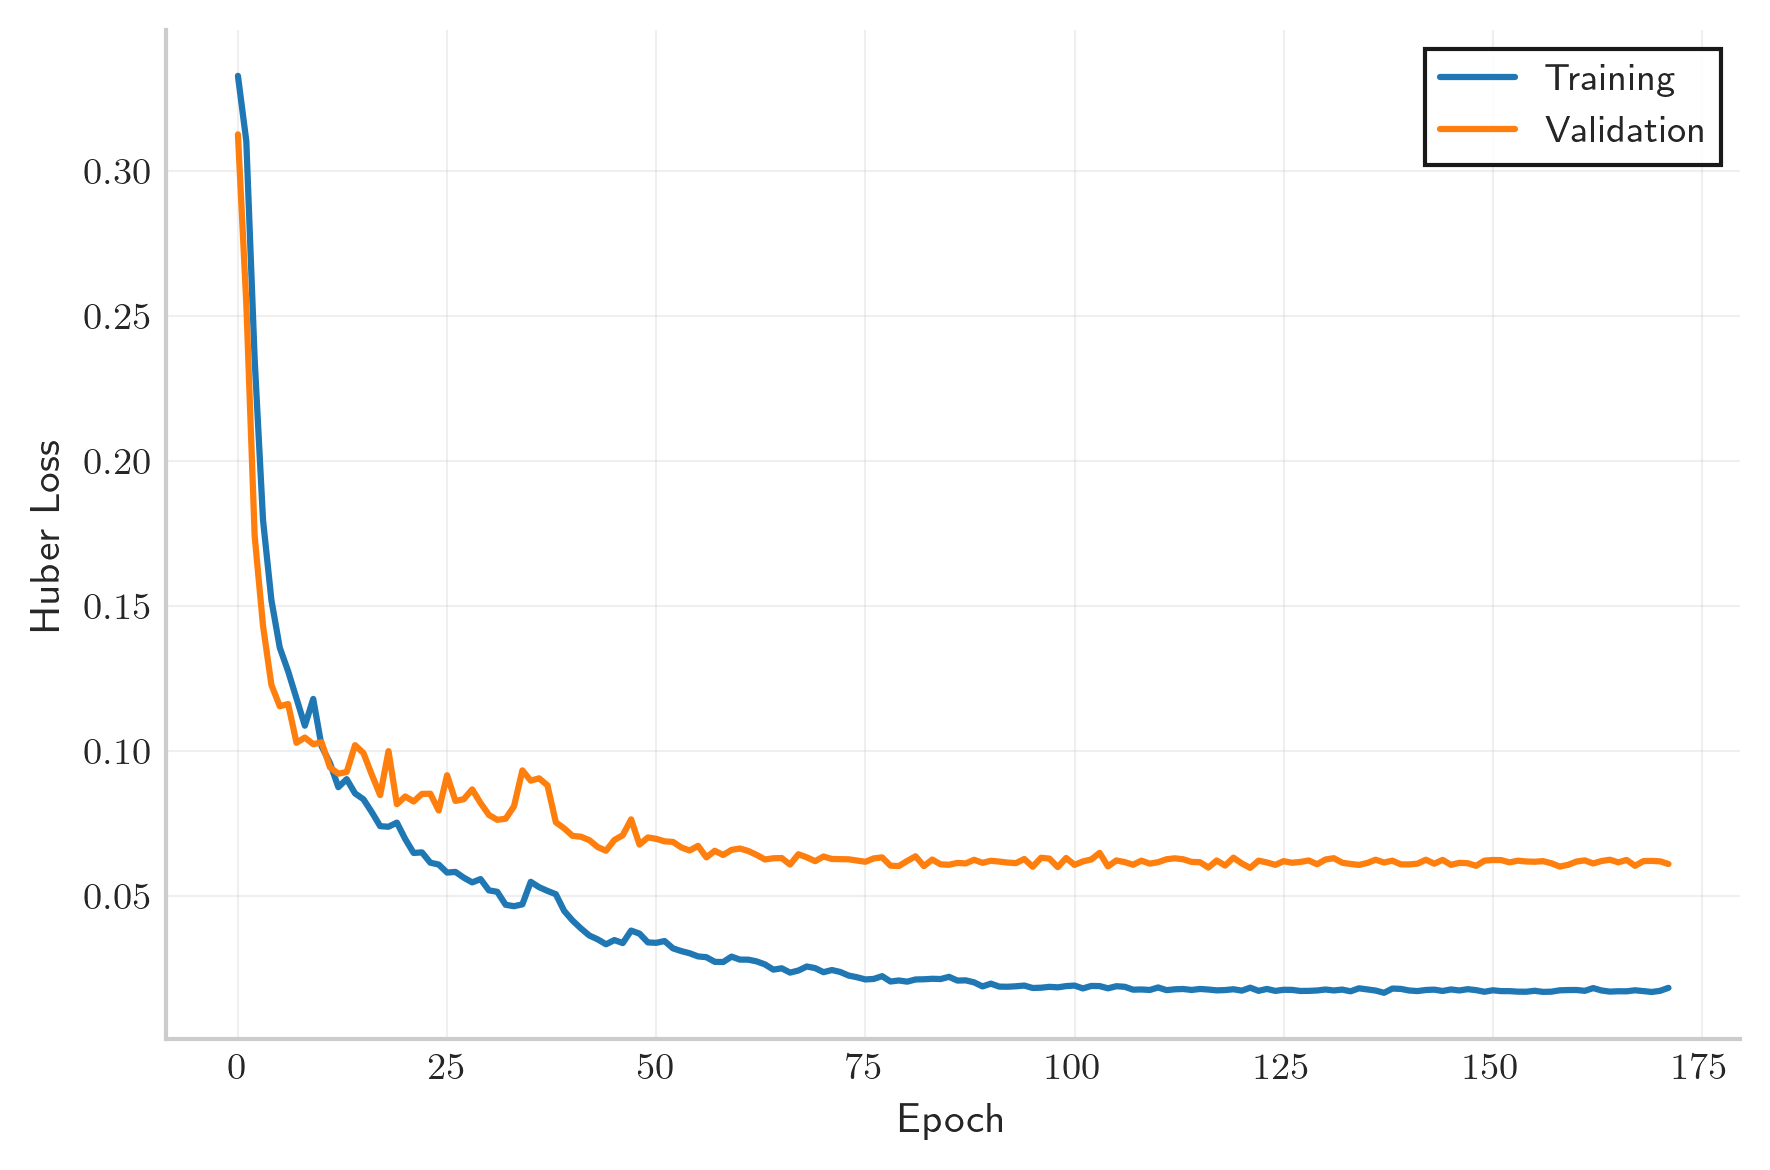

In [12]:
# Load history from file
history_multi = np.load('history_multi_affine.npy', allow_pickle=True).item()
history_train = history_multi['train']
history_val = history_multi['val']

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history_train, label='Training', linewidth=1.5)
ax.plot(history_val, label='Validation', linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Huber Loss')
ax.legend()
ax.tick_params(which='both', direction='in')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Constant curvature model

In [18]:
wrapped_model = torch.load("models/vision/helyx_model_normalized.pt", map_location=device)

model_new = NetCameraBW3x()

model_new.load_state_dict(wrapped_model.state_dict(), strict=False)

model_new.head = nn.Sequential(
    nn.Flatten(),
    nn.Linear(1280, 512),
    nn.LeakyReLU(),
    nn.Linear(512, 9)
)

model_new = model_new.to(device)

total_params = sum(p.numel() for p in model_new.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

criterion = nn.HuberLoss(delta=1.0)
optimizer = optim.Adam(model_new.parameters(), lr=1e-3, weight_decay=5e-6)

scheduler = LinearLR(optimizer, start_factor=1e-3, end_factor=1.0, total_iters=10)
plateau_scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.6, patience=5, verbose=True)

stats = torch.load("const_stats.pt")
mean = stats['mean'].to(device)
std = stats['std'].to(device)

best_val_loss = float('inf')
PATIENCE = 50
counter = 0
history_train = []
history_val = []

scaler = GradScaler()
accumulation_steps = max(1, len(curvature_loaders["const"]["train"]) // 8)
optimizer.zero_grad()
epochs = 500

max_grad_norm = 1.0

angle_idx = [2, 5, 8]
non_angle_idx = [i for i in range(9) if i not in angle_idx]

if True:
    for epoch in range(epochs):
        model_new.train()
        train_losses = []
        total_batches = len(curvature_loaders["const"]["train"])

        for i, (images, labels) in enumerate(curvature_loaders["const"]["train"]):
            images = images.to(device)
            labels = labels.to(device)

            with autocast(device_type='cuda'):
                labels_non_angle = (labels[:, non_angle_idx] - mean[non_angle_idx]) / std[non_angle_idx]
                phi_true = labels[:, angle_idx]

                labels_ext = torch.cat((
                    labels_non_angle,
                    torch.sin(phi_true),
                    torch.cos(phi_true)),
                dim=1)

                preds_raw = model_new(images)
                preds_non_angle = preds_raw[:, non_angle_idx]
                phi_pred = preds_raw[:, angle_idx]
                preds_ext = torch.cat((
                    preds_non_angle,
                    torch.sin(phi_pred),
                    torch.cos(phi_pred)),
                dim=1)

                loss = criterion(preds_ext, labels_ext)

            loss = loss / accumulation_steps
            scaler.scale(loss).backward()

            train_losses.append(loss.item() * accumulation_steps)

            progress = (i + 1) / total_batches * 100
            sys.stdout.write(f"\rEpoch {epoch + 1}: {progress:.1f}%")
            sys.stdout.flush()

            if (i + 1) % accumulation_steps == 0 or (i + 1) == total_batches:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model_new.parameters(), max_grad_norm)
                
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

        model_new.eval()
        val_losses = []

        with torch.no_grad():
            for images, labels in curvature_loaders["const"]["val"]:
                images = images.to(device)
                labels = labels.to(device)

                with autocast(device_type='cuda'):
                    labels_non_angle = (labels[:, non_angle_idx] - mean[non_angle_idx]) / std[non_angle_idx]
                    phi_true = labels[:, angle_idx]

                    labels_ext = torch.cat((
                        labels_non_angle,
                        torch.sin(phi_true),
                        torch.cos(phi_true)),
                    dim=1)

                    preds_raw = model_new(images)
                    preds_non_angle = preds_raw[:, non_angle_idx]
                    phi_pred = preds_raw[:, angle_idx]
                    preds_ext = torch.cat((
                        preds_non_angle,
                        torch.sin(phi_pred),
                        torch.cos(phi_pred)),
                    dim=1)

                    loss = criterion(preds_ext, labels_ext)

                val_losses.append(loss.item())

        avg_train_loss = np.mean(train_losses)
        avg_val_loss = np.mean(val_losses)
        
        # Step schedulers
        if epoch < 10:
            scheduler.step()
        plateau_scheduler.step(avg_val_loss)

        history_train.append(avg_train_loss)
        history_val.append(avg_val_loss)

        sys.stdout.write("\r")
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch + 1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {current_lr:.6f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model_new, "helyx_const_curvature_normalized.pt")
            counter = 0
        else:
            counter += 1
            if counter >= PATIENCE:
                print("Early stopping triggered.")
                break

    # Save training history
    history_multi = {
        'train': history_train,
        'val': history_val
    }
    np.save('history_multi_const.npy', history_multi)

    del model_new, stats, mean, std
    del optimizer, scheduler, plateau_scheduler, scaler
    del history_train, history_val

model = torch.load("helyx_const_curvature_normalized.pt")
stats = torch.load("const_stats.pt")

model = model.to(device)
mean = stats['mean'].to(device)
std = stats['std'].to(device)

mean[angle_idx] = 0.0
std[angle_idx] = 1.0

if hasattr(model, 'module'):
    actual_model = model.module
else:
    actual_model = model

final_model = DenormalizedModel(actual_model, mean, std)
scripted_model = torch.jit.script(final_model)
scripted_model.save("models/curvature/constant_model.pt")

del final_model, scripted_model, stats

Total trainable parameters: 2,884,361
Epoch 1 | Train Loss: 0.3840 | Val Loss: 0.3706 | LR: 0.000101
Epoch 2 | Train Loss: 0.3555 | Val Loss: 0.2998 | LR: 0.000201
Epoch 3 | Train Loss: 0.2663 | Val Loss: 0.1942 | LR: 0.000301
Epoch 4 | Train Loss: 0.1975 | Val Loss: 0.1571 | LR: 0.000401
Epoch 5 | Train Loss: 0.1654 | Val Loss: 0.1391 | LR: 0.000501
Epoch 6 | Train Loss: 0.1446 | Val Loss: 0.1236 | LR: 0.000600
Epoch 7 | Train Loss: 0.1307 | Val Loss: 0.1187 | LR: 0.000700
Epoch 8 | Train Loss: 0.1261 | Val Loss: 0.1236 | LR: 0.000800
Epoch 9 | Train Loss: 0.1172 | Val Loss: 0.1150 | LR: 0.000900
Epoch 10 | Train Loss: 0.1058 | Val Loss: 0.1106 | LR: 0.001000
Epoch 11 | Train Loss: 0.1010 | Val Loss: 0.1237 | LR: 0.001000
Epoch 12 | Train Loss: 0.0989 | Val Loss: 0.1033 | LR: 0.001000
Epoch 13 | Train Loss: 0.0939 | Val Loss: 0.1122 | LR: 0.001000
Epoch 14 | Train Loss: 0.0892 | Val Loss: 0.0989 | LR: 0.001000
Epoch 15 | Train Loss: 0.0932 | Val Loss: 0.1200 | LR: 0.001000
Epoch 16 | 

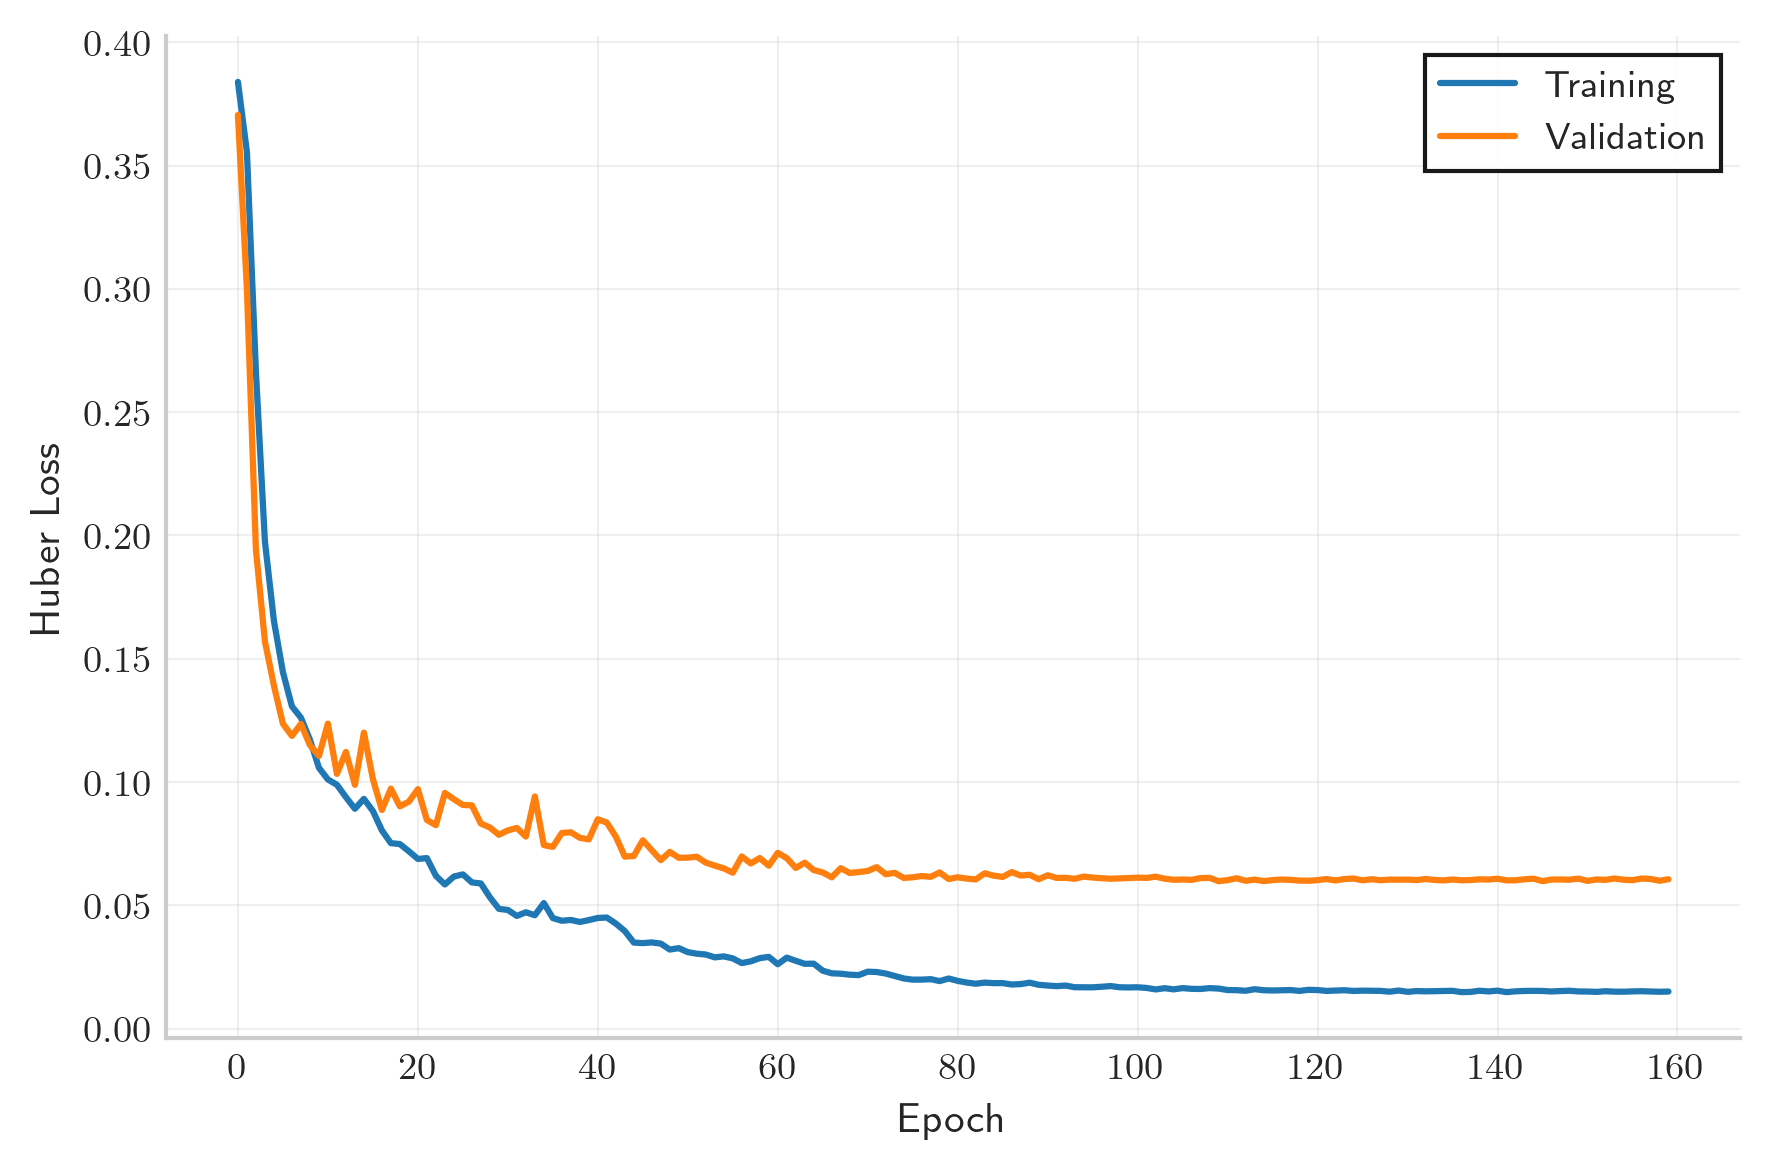

In [13]:
# Load history from file
history_multi = np.load('history_multi_const.npy', allow_pickle=True).item()
history_train = history_multi['train']
history_val = history_multi['val']

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history_train, label='Training', linewidth=1.5)
ax.plot(history_val, label='Validation', linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Huber Loss')
ax.legend()
ax.tick_params(which='both', direction='in')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 😓 Training of Forward Kinematics model

In [20]:
class NetKinematics(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ELU(),
            nn.Linear(128, 128),
            nn.ELU(),
            nn.Linear(128, 128),
            nn.ELU(),
            nn.Linear(128, 128),
            nn.ELU(),
            nn.Linear(128, output_dim)
        )

    def forward(self, x):
        return self.layers(x)

class DenormalizedModel(nn.Module):
    def __init__(self, base_model, mean, std):
        super().__init__()
        self.base_model = base_model
        self.register_buffer("mean", mean)
        self.register_buffer("std", std)

    def forward(self, x):
        out = self.base_model(x)
        return out * self.std + self.mean

Forward Kinematics

In [21]:
model = NetKinematics(input_dim=9, output_dim=6).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

criterion = nn.HuberLoss(delta=1.0)
max_grad_norm = 1.0

stats_real = torch.load("end_effector_stats.pt")
mean_real = stats_real['mean'].to(device)
std_real = stats_real['std'].to(device)

position_indices = [0, 1, 2]
angle_indices = [3, 4, 5]

optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-6)
plateau_scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.9, patience=5, verbose=True)

best_val_loss = float('inf')
PATIENCE = 50
counter = 0
history_train_real = []
history_val_real = []

scaler = GradScaler()
accumulation_steps = max(1, len(train_loader_FK) // 8)
optimizer.zero_grad()
epochs_finetune = 800

if True:
    for epoch in range(epochs_finetune):
        model.train()
        train_losses = []
        total_batches = len(train_loader_FK)

        for i, (deltal, pose) in enumerate(train_loader_FK):
            deltal = deltal.to(device)
            pose = pose.to(device)

            with autocast(device_type='cuda'):
                pose_pos_norm = (pose[:, position_indices] - mean_real[position_indices]) / std_real[position_indices]
                angles_true = pose[:, angle_indices]

                pose_ext = torch.cat((
                    pose_pos_norm,
                    torch.sin(angles_true),
                    torch.cos(angles_true)
                ), dim=1)

                preds = model(deltal)
                preds_pos = preds[:, position_indices]
                preds_angles = preds[:, angle_indices]
                
                preds_ext = torch.cat((
                    preds_pos,
                    torch.sin(preds_angles),
                    torch.cos(preds_angles)
                ), dim=1)

                loss = criterion(preds_ext, pose_ext)

            loss = loss / accumulation_steps
            scaler.scale(loss).backward()
            train_losses.append(loss.item() * accumulation_steps)

            progress = (i + 1) / total_batches * 100
            sys.stdout.write(f"\rEpoch {epoch + 1}: {progress:.1f}%")
            sys.stdout.flush()

            if (i + 1) % accumulation_steps == 0 or (i + 1) == total_batches:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

        model.eval()
        val_losses = []

        with torch.no_grad():
            for deltal, pose in val_loader_FK:
                deltal = deltal.to(device)
                pose = pose.to(device)

                with autocast(device_type='cuda'):
                    pose_pos_norm = (pose[:, position_indices] - mean_real[position_indices]) / std_real[position_indices]
                    angles_true = pose[:, angle_indices]

                    pose_ext = torch.cat((
                        pose_pos_norm,
                        torch.sin(angles_true),
                        torch.cos(angles_true)
                    ), dim=1)

                    preds = model(deltal)
                    preds_pos = preds[:, position_indices]
                    preds_angles = preds[:, angle_indices]
                    
                    preds_ext = torch.cat((
                        preds_pos,
                        torch.sin(preds_angles),
                        torch.cos(preds_angles)
                    ), dim=1)

                    loss = criterion(preds_ext, pose_ext)

                val_losses.append(loss.item())

        avg_train_loss = np.mean(train_losses)
        avg_val_loss = np.mean(val_losses)
        
        plateau_scheduler.step(avg_val_loss)

        history_train_real.append(avg_train_loss)
        history_val_real.append(avg_val_loss)

        sys.stdout.write("\r")
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch + 1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {current_lr:.6f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model, "FK_normalized.pt")
            counter = 0
        else:
            counter += 1
            if counter >= PATIENCE:
                print("Early stopping triggered.")
                break

    # Save training history
    history_multi = {
        'train': history_train,
        'val': history_val
    }
    np.save('history_multi_fk.npy', history_multi)

model = torch.load("FK_normalized.pt")
model = model.to(device)

mean_real[angle_indices] = 0.0
std_real[angle_indices] = 1.0

if hasattr(model, 'module'):
    actual_model = model.module
else:
    actual_model = model

final_model = DenormalizedModel(actual_model, mean_real, std_real)
scripted_model = torch.jit.script(final_model)
scripted_model.save("models/kinematics/FK_model.pt")

del final_model, scripted_model, stats_real

Total trainable parameters: 51,590
Epoch 1 | Train Loss: 0.1178 | Val Loss: 0.0601 | LR: 0.001000
Epoch 2 | Train Loss: 0.0527 | Val Loss: 0.0444 | LR: 0.001000
Epoch 3 | Train Loss: 0.0381 | Val Loss: 0.0320 | LR: 0.001000
Epoch 4 | Train Loss: 0.0266 | Val Loss: 0.0221 | LR: 0.001000
Epoch 5 | Train Loss: 0.0193 | Val Loss: 0.0183 | LR: 0.001000
Epoch 6 | Train Loss: 0.0169 | Val Loss: 0.0167 | LR: 0.001000
Epoch 7 | Train Loss: 0.0155 | Val Loss: 0.0184 | LR: 0.001000
Epoch 8 | Train Loss: 0.0151 | Val Loss: 0.0150 | LR: 0.001000
Epoch 9 | Train Loss: 0.0137 | Val Loss: 0.0148 | LR: 0.001000
Epoch 10 | Train Loss: 0.0133 | Val Loss: 0.0145 | LR: 0.001000
Epoch 11 | Train Loss: 0.0131 | Val Loss: 0.0157 | LR: 0.001000
Epoch 12 | Train Loss: 0.0129 | Val Loss: 0.0136 | LR: 0.001000
Epoch 13 | Train Loss: 0.0121 | Val Loss: 0.0129 | LR: 0.001000
Epoch 14 | Train Loss: 0.0118 | Val Loss: 0.0140 | LR: 0.001000
Epoch 15 | Train Loss: 0.0122 | Val Loss: 0.0142 | LR: 0.001000
Epoch 16 | Tra

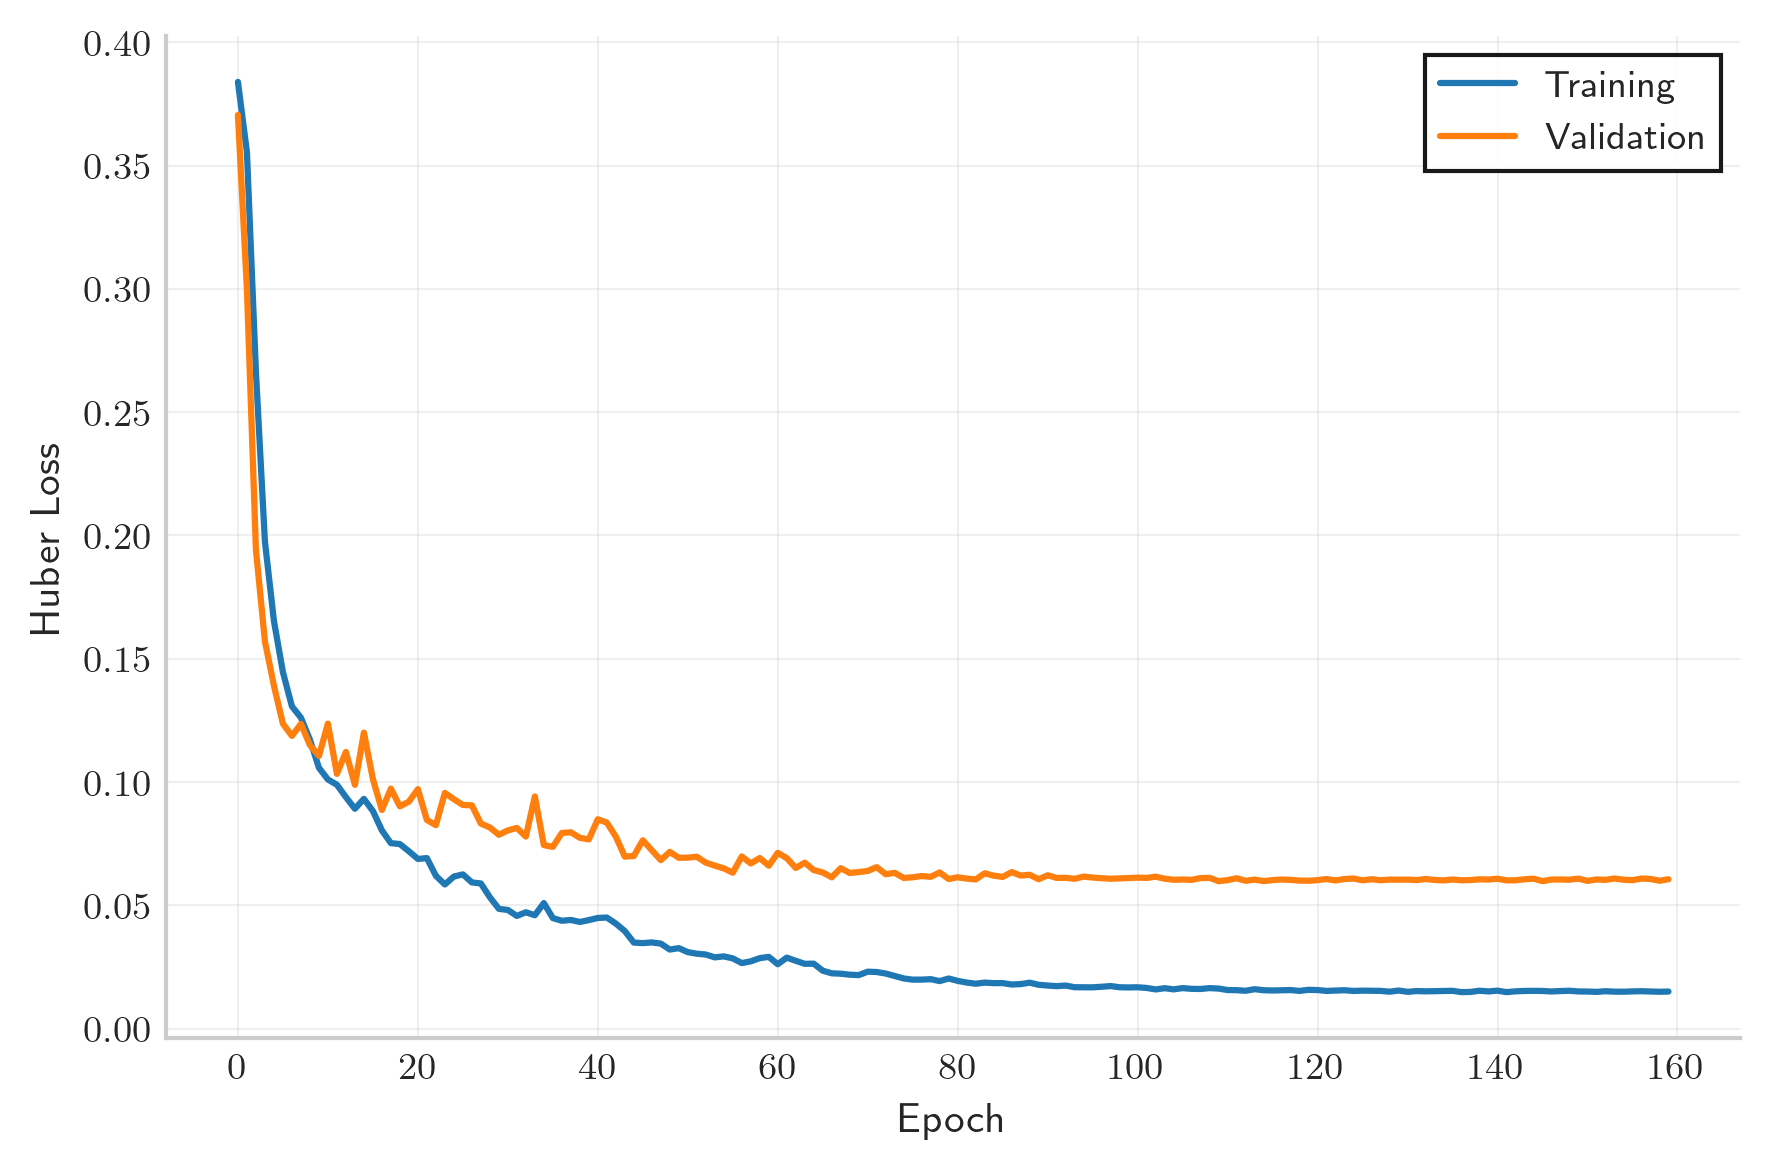

In [14]:
# Load history from file
history_multi = np.load('history_multi_fk.npy', allow_pickle=True).item()
history_train = history_multi['train']
history_val = history_multi['val']

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history_train, label='Training', linewidth=1.5)
ax.plot(history_val, label='Validation', linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Huber Loss')
ax.legend()
ax.tick_params(which='both', direction='in')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Inverse Kinematics

In [23]:
class IKLoss(nn.Module):
    """
    Train the Inverse Kinematics model using the Forward Kinematics model.
    DELTAL is penalized as a secondary objective.
    """
    def __init__(self, fk_model, pose_mean, pose_std, deltal_mean, deltal_std, deltal_weight=1e-2):
        super().__init__()
        self.fk_model = fk_model
        self.pose_mean = pose_mean
        self.pose_std = pose_std
        self.deltal_mean = deltal_mean
        self.deltal_std = deltal_std
        self.pose_criterion = nn.HuberLoss(delta=1.0)
        self.weight = deltal_weight
       
    def forward(self, predicted_deltal_norm, target_pose_norm):
        with torch.no_grad():
           self.fk_model.eval()
       
        predicted_deltal = predicted_deltal_norm * self.deltal_std + self.deltal_mean
        predicted_pose = self.fk_model(predicted_deltal)
        predicted_pose_norm = (predicted_pose - self.pose_mean) / self.pose_std
       
        pose_loss = self.pose_criterion(predicted_pose_norm, target_pose_norm)
        deltal_reg_loss = torch.mean(predicted_deltal_norm ** 2)
        total_loss = pose_loss + self.weight * deltal_reg_loss
       
        return total_loss

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

fk_model = torch.jit.load("models/kinematics/FK_model.pt", map_location=device)
fk_model.eval()

deltal_stats = torch.load("DELTAL_fk_stats.pt")
deltal_mean = deltal_stats['mean'].to(device)
deltal_std = deltal_stats['std'].to(device)

pose_stats = torch.load("end_effector_stats.pt")
pose_mean = pose_stats['mean'].to(device)
pose_std = pose_stats['std'].to(device)

ik_model = NetKinematics(input_dim=6, output_dim=9).to(device)

total_params = sum(p.numel() for p in ik_model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

criterion = IKLoss(fk_model, pose_mean, pose_std, deltal_mean, deltal_std)
max_grad_norm = 1.0

optimizer = optim.Adam(ik_model.parameters(), lr=1e-3, weight_decay=5e-6)
plateau_scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.9, patience=15, verbose=True)

best_val_loss = float('inf')
PATIENCE = 50
counter = 0
history_train_real = []
history_val_real = []

scaler = GradScaler()
accumulation_steps = max(1, len(train_loader_FK) // 8)
optimizer.zero_grad()
epochs_finetune = 2000

if True:
    for epoch in range(epochs_finetune):
        ik_model.train()
        train_losses = []
        total_batches = len(train_loader_FK)

        for i, (deltal, pose) in enumerate(train_loader_FK):
            deltal = deltal.to(device)
            pose = pose.to(device)
            
            pose_norm = (pose - pose_mean) / pose_std

            with autocast(device_type='cuda'):
                predicted_deltal_norm = ik_model(pose)
                loss = criterion(predicted_deltal_norm, pose_norm)

            loss = loss / accumulation_steps
            scaler.scale(loss).backward()
            train_losses.append(loss.item() * accumulation_steps)

            progress = (i + 1) / total_batches * 100
            sys.stdout.write(f"\rEpoch {epoch + 1}: {progress:.1f}%")
            sys.stdout.flush()

            if (i + 1) % accumulation_steps == 0 or (i + 1) == total_batches:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(ik_model.parameters(), max_grad_norm)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

        ik_model.eval()
        val_losses = []

        with torch.no_grad():
            for deltal, pose in val_loader_FK:
                deltal = deltal.to(device)
                pose = pose.to(device)
                
                pose_norm = (pose - pose_mean) / pose_std

                with autocast(device_type='cuda'):
                    predicted_deltal_norm = ik_model(pose)
                    loss = criterion(predicted_deltal_norm, pose_norm)

                val_losses.append(loss.item())

        avg_train_loss = np.mean(train_losses)
        avg_val_loss = np.mean(val_losses)
        
        plateau_scheduler.step(avg_val_loss)

        history_train_real.append(avg_train_loss)
        history_val_real.append(avg_val_loss)

        sys.stdout.write("\r")
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch + 1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {current_lr:.6f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(ik_model, "IK_normalized.pt")
            counter = 0
        else:
            counter += 1
            if counter >= PATIENCE:
                print("Early stopping triggered.")
                break

    # Save training history
    history_multi = {
        'train': history_train,
        'val': history_val
    }
    np.save('history_multi_ik.npy', history_multi)

ik_model = torch.load("IK_normalized.pt")
ik_model = ik_model.to(device)

if hasattr(ik_model, 'module'):
    actual_model = ik_model.module
else:
    actual_model = ik_model

final_ik_model = DenormalizedModel(actual_model, deltal_mean, deltal_std)
scripted_ik_model = torch.jit.script(final_ik_model)
scripted_ik_model.save("models/kinematics/IK_model.pt")

del final_ik_model, scripted_ik_model, pose_stats, deltal_stats

Total trainable parameters: 51,593
Epoch 1 | Train Loss: 0.9612 | Val Loss: 0.2569 | LR: 0.001000
Epoch 2 | Train Loss: 0.1714 | Val Loss: 0.1036 | LR: 0.001000
Epoch 3 | Train Loss: 0.0900 | Val Loss: 0.0750 | LR: 0.001000
Epoch 4 | Train Loss: 0.0708 | Val Loss: 0.0777 | LR: 0.001000
Epoch 5 | Train Loss: 0.0663 | Val Loss: 0.0690 | LR: 0.001000
Epoch 6 | Train Loss: 0.0627 | Val Loss: 0.0652 | LR: 0.001000
Epoch 7 | Train Loss: 0.0652 | Val Loss: 0.0770 | LR: 0.001000
Epoch 8 | Train Loss: 0.0708 | Val Loss: 0.0813 | LR: 0.001000
Epoch 9 | Train Loss: 0.0701 | Val Loss: 0.0611 | LR: 0.001000
Epoch 10 | Train Loss: 0.0634 | Val Loss: 0.0638 | LR: 0.001000
Epoch 11 | Train Loss: 0.0600 | Val Loss: 0.0627 | LR: 0.001000
Epoch 12 | Train Loss: 0.0603 | Val Loss: 0.0634 | LR: 0.001000
Epoch 13 | Train Loss: 0.0573 | Val Loss: 0.0635 | LR: 0.001000
Epoch 14 | Train Loss: 0.0579 | Val Loss: 0.0581 | LR: 0.001000
Epoch 15 | Train Loss: 0.0559 | Val Loss: 0.0587 | LR: 0.001000
Epoch 16 | Tra

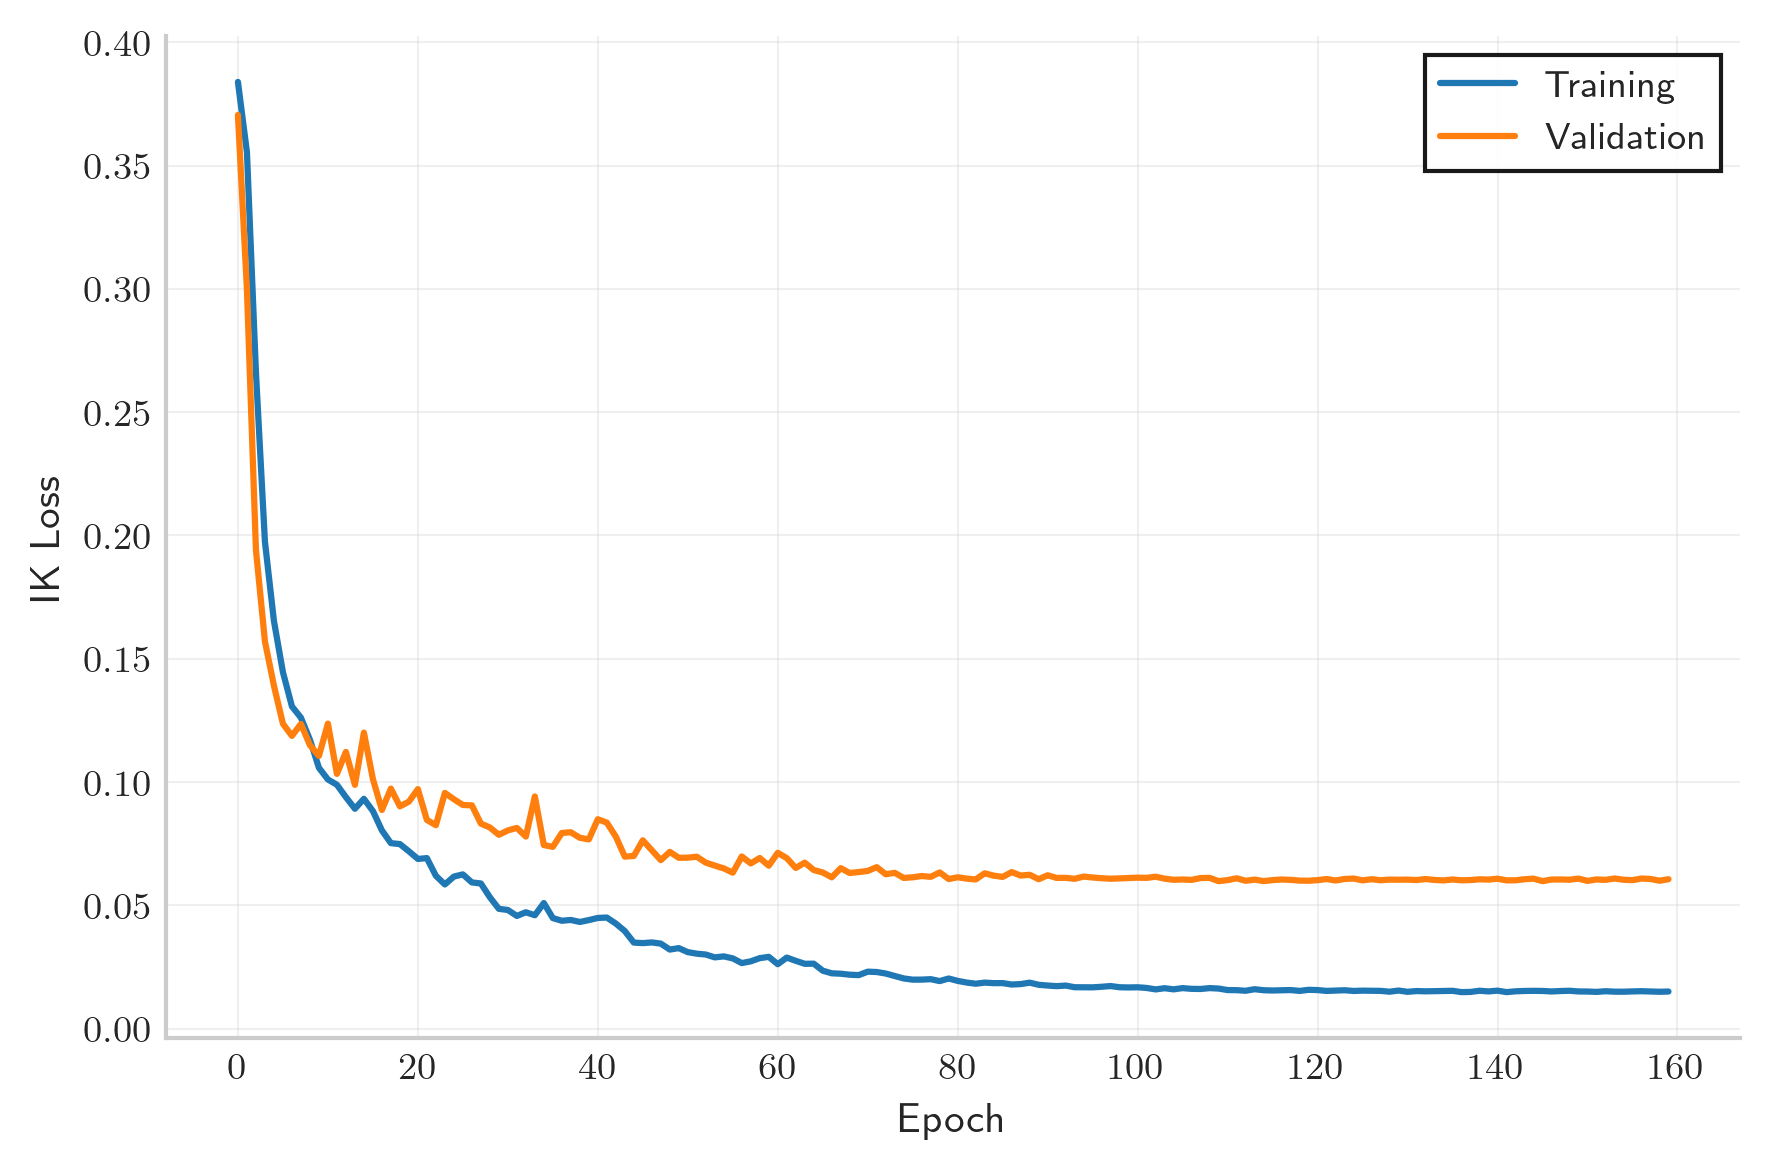

In [15]:
# Load history from file
history_multi = np.load('history_multi_ik.npy', allow_pickle=True).item()
history_train = history_multi['train']
history_val = history_multi['val']

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history_train, label='Training', linewidth=1.5)
ax.plot(history_val, label='Validation', linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('IK Loss')
ax.legend()
ax.tick_params(which='both', direction='in')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()